# Machine Learning on Big Data: Sentiment Analysis of Amazon Product Reviews using PySpark

This project focusses on developing predictive machine learning models to leverage a huge dataset of customer reviews to categorise Amazon product reviews according to their rating or sentiment.  Determining whether a text's stated opinion is good, negative, or neutral is known as sentiment analysis, and it is essential for comprehending client feedback and enhancing business plans.  Effective preprocessing and analysis of the textual review data is the aim of this project, which combines big data technologies like Apache Spark with sophisticated natural language processing tools like Gensim for topic modelling and SpaCy for linguistic feature extraction.  Random Forest, Logistic Regression, XGBoost, and Linear Support Vector Machine (SVM) are among the classification methods used to forecast each review's sentiment or rating category.This research is important because it will help e-commerce platforms and marketers monitor brand reputation, improve product suggestions, automatically evaluate consumer sentiment at scale, and customise marketing campaigns based on actual user input.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Initialize Spark Session
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("AmazonReviewAnalysis") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "8g") \
    .getOrCreate()

print("Spark Session Initialized")

Spark Session Initialized


The code starts a Spark session with an 8GB allocation of off-heap memory enabled to effectively manage large-scale data processing.  This configuration offers an effective setting for machine learning and distributed analysis on the dataset of Amazon reviews.

In [ ]:
!pip install numpy==1.24.4


In [ ]:
!pip uninstall -y scipy
!pip install scipy==1.10.1
!pip install gensim==4.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 26.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.9.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
xarray-einstats 0.9.1 requires scipy>=1.11, but you have scipy 1.10.1 which is incompatible.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.10.1 which is incompatible.
jax 0.5.3 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jax 0.5.3 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompatible.
jaxlib 0.5.3 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.3 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompatible.
cvxpy 1.6.7 requires scipy>=1.11.0, but you have scip

In [ ]:
!pip install --force-reinstall numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 28.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.3.2 which is incompatible.
xarray-einstats 0.9.1 requires scipy>=1.11, but you have scipy 1.10.1 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.10.1 which is incompatible.
jax 0.5.3 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompatible.
tensorflow 2.19.0 requires num

In [ ]:
#Install necessary libraries (if not already installed)
!pip install pyspark spacy gensim pandas numpy scikit-learn nltk

#Import necessary libraries
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, isnull
import spacy
import gensim
from gensim.models import TfidfModel
from gensim.corpora import Dictionary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from pyspark.ml.feature import HashingTF, IDF, Tokenizer
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.ensemble import RandomForestClassifier
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

This bit of code installs and imports a whole suite of libraries needed for machine learning, natural language processing, and processing vast amounts of text data.  NLP processing (SpaCy, Gensim, NLTK), large data handling and Spark ML pipelines, data manipulation tools (Pandas, NumPy), and a range of machine learning models and assessment methods from scikit-learn, XGBoost, and PySpark are all included.  It also prepares the environment for thorough analysis and modelling of the Amazon reviews dataset by setting up the required tools for text preparation, such as stopwords and lemmatizers.

# Task 1 - Data Loading and Preprocessing 

Preprocessing and data loading included importing the Amazon reviews dataset into Spark, examining its structure, clearing out any missing or incorrect values, standardising column names, and filtering ratings to make sure that only records that were legitimate and suitable for analysis were kept.  This created a reliable, high-quality dataset ready for further machine learning, feature extraction, NLP processing, and EDA.

In [ ]:
df_spark = spark.read.csv("/content/AMAZON REVIEWS.csv", header=True, inferSchema=True)
print("Dataset loaded")

Dataset loaded


This code automatically infers the schema and treats the first row as the header when loading the Amazon reviews dataset from a CSV file into a Spark DataFrame.  Spark's distributed data processing features enable the effective handling of big datasets for pretreatment and further analysis.

In [ ]:
#Display schema and a few rows to understand the data
df_spark.printSchema()
df_spark.show(5, truncate=True)

#Check the number of columns to ensure it meets the condition (>= 5)
print(f"Number of columns: {len(df_spark.columns)}")


#Identify relevant columns for analysis (e.g., 'review_text', 'star_rating', 'product_id', 'user_id', 'timestamp')
# Ensure 'reviewText' and 'rating' columns exist for text classification

#Rename columns for consistency
df_spark = df_spark.withColumnRenamed("reviewText", "review_text") \
                   .withColumnRenamed("rating", "star_rating")

#Show null value counts for all columns
#print("Null value counts before cleaning:")
df_spark.select([count(when(isnull(c), c)).alias(c) for c in df_spark.columns])

#Drop all rows that contain any null values in any column
df_spark = df_spark.na.drop()

#Convert star_rating to integer type
df_spark = df_spark.withColumn("star_rating", col("star_rating").cast("integer"))

#Filter star ratings between 1 and 5 (valid review ratings only)
df_spark = df_spark.filter((col("star_rating") >= 1) & (col("star_rating") <= 5))

#Show updated null value counts (should all be 0)
print(" Null value  are cleaned")
df_spark.select([count(when(isnull(c), c)).alias(c) for c in df_spark.columns])

#Show distribution of star ratings
#print("Cleaned Star Rating Distribution:")
df_spark.groupBy("star_rating").count().orderBy("star_rating")

root
 |-- userName: string (nullable = true)
 |-- verified: string (nullable = true)
 |-- itemName: string (nullable = true)
 |-- description: string (nullable = true)
 |-- image: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- feature: string (nullable = true)
 |-- category: string (nullable = true)
 |-- price: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- reviewTime: string (nullable = true)
 |-- summary: string (nullable = true)
 |-- review_text: string (nullable = true)
 |-- vote: string (nullable = true)

+------------+--------+--------------------+--------------------+--------------------+---------------+--------------------+--------------------+--------------------+-----------+----------+--------------------+--------------------+----+
|    userName|verified|            itemName|         description|               image|          brand|             feature|            category|               price|star_rating|reviewTime|             

DataFrame[star_rating: int, count: bigint]

**Present the schema and preview the data:**

 Printing the DataFrame's structure, including column names and data types, is done via df_spark.printSchema().

 df_spark.show(5, truncate=True) provides a brief overview of the dataset's real content by displaying the first five rows.

 **Verify the amount of columns:**

 prints the dataset's total number of columns to make sure it satisfies the required minimum (at least 5 columns), ensuring that there are sufficient data characteristics for a useful analysis.

 **To ensure uniformity, rename the columns:**

 Renames the review To make column names more accessible and simpler to refer to in code, text should be changed to review_text and rating should be changed to star_rating.

 **Locate and deal with missing values:**

 Determines how much data is missing by counting the null values in each column.

 Eliminates all rows with null values in order to clean the dataset and prevent incomplete records from affecting further processing and modelling.

 **Create an integer rating column and apply a filter:**

 Converts star_rating's native data type to an integer so that it may be processed numerically.

 Selects only genuine review ratings by eliminating any that fall outside the acceptable range of 1 to 5.

 **Verify cleansing and check the distribution of the data:**

 After cleaning, it is verified that no null values remain.

 Shows how many reviews there are for each star rating, which aids in understanding the target variable's distribution—a crucial insight for modelling.

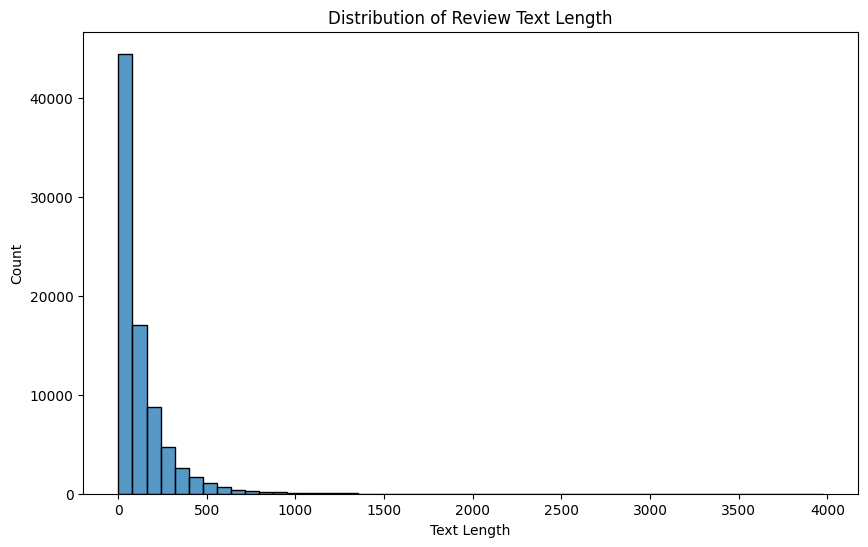

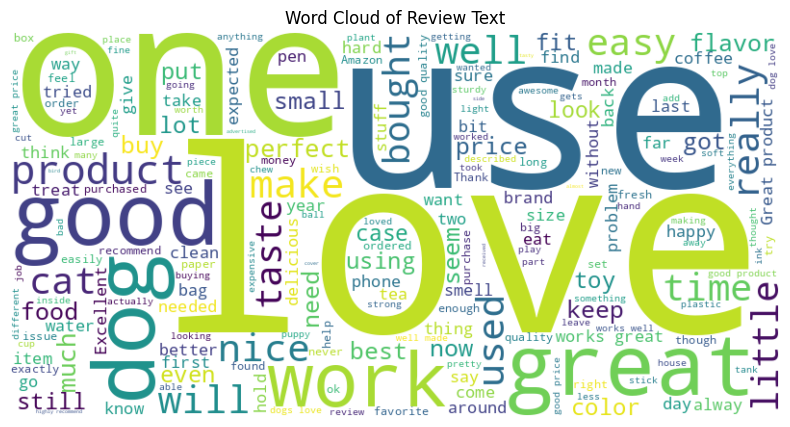

In [ ]:
#For initial EDA and to visualize, convert a sample to Pandas.
#If the dataset is extremely large, consider sampling.
#For example, take 10% of the data or a fixed number of rows.
sample_size = min(df_spark.count(), 100000) #Adjust sample size as needed
df_pandas = df_spark.sample(False, sample_size / df_spark.count(), seed=42).toPandas()

#Basic text length distribution
df_pandas['text_length'] = df_pandas['review_text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df_pandas['text_length'], bins=50)
plt.title('Distribution of Review Text Length')
plt.xlabel('Text Length')
plt.ylabel('Count')
plt.show()

#Word cloud (optional, but good for visualization)
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df_pandas['review_text'].dropna().astype(str)))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Text')
plt.show()

**This code samples, visualises text length, and generates a word cloud in order to do an initial Exploratory Data Analysis (EDA) on the Amazon reviews:**

 **Using data samples for visualisation:**

 EDA is made manageable by calculating a sample size (up to 100,000 rows) without analysing the entire dataset, which might be rather big.

 selects the sample at random using df_spark.sample() and then transforms it into a Pandas DataFrame for simpler visualisation.

 **Text length distribution:**

 The amount of characters in each review is determined and a new column called text_length is created.

 The distribution of review lengths is visualised using Seaborn's histogram plot (histplot), which highlights possible outliers and typical text sizes.

 **The visualisation of a word cloud:**

Identifies the most common terms in customer reviews by creating a word cloud from all of the review texts.

Greater frequency is shown by larger words in the cloud, which offers a clear picture of the dataset's recurring topics.

In [ ]:
#Load SpaCy model for advanced NLP tasks
#Ensure you have downloaded the model: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

#Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_spacy_gensim(text):
    if not isinstance(text, str):
        return ""
    #Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|@\S+|#\S+', '', text)
    #Remove HTML tags if any
    text = re.sub(r'<.*?>', '', text)
    #Convert to lowercase
    text = text.lower()
    #Tokenization and lemmatization using SpaCy
    doc = nlp(text)
    lemmas = [lemmatizer.lemmatize(token.lemma_) for token in doc if token.is_alpha and token.lemma_ not in stop_words]
    return " ".join(lemmas)

#Register the UDF for Spark if processing large datasets directly
from pyspark.sql.types import StringType
from pyspark.sql.functions import udf

clean_text_udf = udf(clean_text_spacy_gensim, StringType())

#Apply cleaning to the Spark DataFrame (if the dataset is very large)
#For smaller datasets, converting to pandas and then processing might be faster for some steps.
#Here we apply to a Pandas DataFrame for easier debugging and visualization
df_pandas['cleaned_review_text'] = df_pandas['review_text'].apply(clean_text_spacy_gensim)

#Show examples of cleaned text
print("Original vs. Cleaned Text Examples:")
for i in range(5):
    if i < len(df_pandas):
        print(f"Original: {df_pandas['review_text'].iloc[i]}")
        print(f"Cleaned: {df_pandas['cleaned_review_text'].iloc[i]}\n")

#Tokenize the cleaned text into a list of words
df_pandas['tokens'] = df_pandas['cleaned_review_text'].apply(lambda x: x.split())

#Create a Gensim Dictionary
dictionary = Dictionary(df_pandas['tokens'])

#Filter out extreme values (words that appear in too few or too many documents)
dictionary.filter_extremes(no_below=5, no_above=0.5) #Adjust these parameters as needed

#Create a Gensim Corpus (Bag-of-Words representation)
corpus = [dictionary.doc2bow(tokens) for tokens in df_pandas['tokens']]

print(f"Number of unique tokens (after filtering): {len(dictionary)}")
print(f"Number of documents in corpus: {len(corpus)}")
#Train the TF-IDF model
tfidf_model = TfidfModel(corpus)

#Apply TF-IDF transformation to the corpus
corpus_tfidf = tfidf_model[corpus]

#Example of TF-IDF vectors for the first document
print("\nTF-IDF vector for the first document:")
print(corpus_tfidf[0])

Original vs. Cleaned Text Examples:
Original: Perfect for kombucha
Cleaned: perfect kombucha

Original: I LOVE THEM!! I bought them at Micheals our of curiosity and wanting to try a different colored pencil. I own Crayola, Prisma and Faber Castell. These colored pencils are very pigmented and there is no wood around. So, you basically get more product for your money! They also don't break as easily. They are very strong and resist breaking than ones I have used with wood around the actual pigment. I used the 40% coupon on them and I am so pleased with them, but I do wish they had a bigger set than just the 24 set. If you have a chance to purchase these, I would say do so but use a coupon with it at Micheals. You will not be disappointed. I use it for when I'm coloring in my Adult coloring book. (Super sorry about the quality of the pictures, but they are very smooth in comparison to the picture's depiction.)
Cleaned: I love I buy micheal curiosity want try different colored pencil I cr

**This code uses SpaCy, NLTK, and Gensim to do text cleaning, tokenisation, and feature extraction for the dataset of Amazon reviews:**

 **NLP tools to load:**

 Loads the en_core_web_sm model from SpaCy for part-of-speech tagging, lemmatisation, and advanced tokenisation.

 NLTK's set of English stopwords and a lemmatizer for word normalisation are initialised.

 **Personalised cleaning feature:**

 HTML tags, hashtags, mentions, and URLs are eliminated using clean_text_spacy_gensim().

 Text is converted to lowercase.

 Employs lemmatisation, eliminates stopwords, filters alphabetic words, tokenises using SpaCy, and produces clean, normalised text.

 **Connecting Spark and Pandas:**

 Outlines a Spark UDF for processing on a big scale.

 Applies cleanup to the Pandas example DataFrame to facilitate visualisation and debugging.

 Displays instances of the original and cleaned text side by side.

 **Creation of dictionaries and tokenisation:**

 Creates tokens from cleaned text.

 Maps words to IDs in a Gensim dictionary.

 Removes terms that are too frequent (no_above=0.5) and uncommon (no_below=5).

 **TF-IDF with Bag-of-Words transformation:**

 Creates a Bag-of-Words (BOW) representation for every review.

 Trains a TF-IDF model to assign value to words in various texts.

 Shows the vector for the first document and applies the TF-IDF transformation to every review.

In [ ]:
#Prepare Data for Scikit-learn Machine Learning
print("\nPreparing data for Scikit-learn (converting TF-IDF to sparse matrix)...")
from scipy.sparse import lil_matrix
from sklearn.preprocessing import LabelEncoder #New import!

#Ensure corpus_tfidf is not empty
if not corpus_tfidf:
    print("Error: corpus_tfidf is empty. Cannot create feature matrix.")
    X = None
    y = None
    #Crucial: set df_pandas to empty or None to prevent issues later
    df_pandas_for_ml = pd.DataFrame() #Create an empty DataFrame
else:
    num_docs = len(corpus_tfidf)
    num_features = len(dictionary) #This is the vocabulary size after filtering
    X_sparse = lil_matrix((num_docs, num_features))

    for i, doc in enumerate(corpus_tfidf):
        for id_val, freq_val in doc:
            if id_val < num_features: #Ensure ID is within bounds
                X_sparse[i, id_val] = freq_val

    X = X_sparse.tocsr() #Convert to CSR for efficient row slicing

    #Start of Combined Filtering and Alignment
    #Create a working copy of df_pandas that will be filtered alongside X
    #It's important to use .copy() to avoid SettingWithCopyWarning
    df_pandas_for_ml = df_pandas.copy()

    #Step 1: Filter out NaNs in 'star_rating'
    nan_count_y = df_pandas_for_ml['star_rating'].isnull().sum()
    if nan_count_y > 0:
        print(f"Warning: {nan_count_y} NaN values found in 'star_rating'. Dropping these rows.")
        non_nan_mask = df_pandas_for_ml['star_rating'].notnull()
        df_pandas_for_ml = df_pandas_for_ml[non_nan_mask]
        X = X[non_nan_mask]

    #Step 2: Filter to include only valid star ratings (1 to 5)
    #This addresses the '25, 50, 110...' issue
    valid_star_rating_mask = (df_pandas_for_ml['star_rating'] >= 1) & (df_pandas_for_ml['star_rating'] <= 5)
    df_pandas_for_ml = df_pandas_for_ml[valid_star_rating_mask]
    X = X[valid_star_rating_mask] #Apply the same filter to X

    initial_y_values = df_pandas_for_ml['star_rating'].values
    print(f"\nOriginal unique y values before encoding: {np.unique(initial_y_values)}")

    #Step 3: Label Encode star ratings to 0-indexed contiguous integers for classification
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(initial_y_values) #This will convert [1,2,3,4,5] to [0,1,2,3,4]
    print(f"Encoded unique y values for classification: {np.unique(y)}")

    #Step 4: Filter out classes with only 1 sample if stratification is desired
    #This addresses the "least populated class" error for train_test_split
    print("\nChecking class distribution in y (after filtering and encoding) before splitting for stratification:")
    unique_classes, counts = np.unique(y, return_counts=True)
    for cls, count in zip(unique_classes, counts):
        print(f"Class {cls}: {count} samples")

    problematic_classes = unique_classes[counts < 2]
    if len(problematic_classes) > 0:
        print(f"\nWARNING: Classes {problematic_classes} have fewer than 2 samples. Removing them for stratification.")
        keep_mask_stratify = ~np.isin(y, problematic_classes) #Name changed to avoid conflict
        df_pandas_for_ml = df_pandas_for_ml[keep_mask_stratify] #Apply this final filter to df_pandas_for_ml
        X = X[keep_mask_stratify]
        y = y[keep_mask_stratify]
        print(f"New y shape after filtering: {y.shape}")
        print("New class distribution:")
        unique_classes, counts = np.unique(y, return_counts=True)
        for cls, count in zip(unique_classes, counts):
            print(f"Class {cls}: {count} samples")
        if np.min(counts) < 2 and len(y) > 0:
            print("\nCRITICAL WARNING: Even after filtering, some classes still have <2 samples. Stratification may still fail.")
            print("Consider removing stratify=y or using a different splitting strategy.")
            can_stratify = False
        else:
            can_stratify = True
    else:
        can_stratify = True
    #End of Combined Filtering and Alignment

#Assume df_pandas is already created (e.g., converted from df_spark)

#Step 1: Clean the review text
def clean_text(text):
    text = str(text).lower()                              #Lowercase
    text = re.sub(r'[^a-z\s]', '', text)                  #Remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()              #Remove extra spaces
    return text

df_pandas['cleaned_text'] = df_pandas['review_text'].apply(clean_text)

#Step 2: Binarize the star_rating
df_pandas['sentiment'] = df_pandas['star_rating'].apply(lambda x: 1 if x >= 4 else 0)

#Step 3: Show sentiment distribution
print("Sentiment Distribution:")
print(df_pandas['sentiment'].value_counts())

#Step 4: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    df_pandas['cleaned_text'],
    df_pandas['sentiment'],
    test_size=0.3,
    random_state=42,
    stratify=df_pandas['sentiment']
)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Preparing data for Scikit-learn (converting TF-IDF to sparse matrix)...

Original unique y values before encoding: [1 2 3 4 5]
Encoded unique y values for classification: [0 1 2 3 4]

Checking class distribution in y (after filtering and encoding) before splitting for stratification:
Class 0: 4652 samples
Class 1: 3332 samples
Class 2: 5878 samples
Class 3: 10666 samples
Class 4: 57887 samples
Sentiment Distribution:
sentiment
1    68553
0    13862
Name: count, dtype: int64
X_train shape: (57690,)
X_test shape: (24725,)
y_train shape: (57690,)
y_test shape: (24725,)


**The cleaned Amazon reviews dataset is prepared for Scikit-learn machine learning models in this part by converting the TF-IDF corpus into a numerical matrix, labelling features, encoding target values, and dividing the dataset into training and testing sets:**

 **The conversion of TF-IDF to Sparse Matrix:**

 Gensim corpus_tfidf is transformed into a SciPy sparse matrix (X_sparse), with each column being a vocabulary word weighted by TF-IDF and each row representing a page.

 Maintains data in CSR format for effective row access and makes sure word IDs are within vocabulary constraints.

 **Alignment and Filtering of Data:**

 Makes a duplicate of the Pandas DataFrame in order to maintain the synchronisation of features (X) and target labels (y).

 Rows without star_rating values are eliminated.

 Only maintains ratings between 1 and 5 that are legitimate.

 In order to ensure model compatibility, the label converts star ratings into integers, such as 1→0 and 5→4.

 Classes with less than two samples are identified and eliminated to avoid stratification mistakes during splitting.

 **Extra Text Cleaning for Models in Scikit-learn:**

 uses the more straightforward regex-based cleaning (clean_text) function to convert text to lowercase and eliminate punctuation, digits, and excess spaces.

 **Sentiment Binarization:**

 ratings ≥4 are classified as positive (1) and ratings <4 as negative (0), forming a binary sentiment label (sentiment).

 **Test/Train Split:**

 Uses stratified sampling to divide the dataset into training and testing sets (70 percent and 30 percent), while preserving class balance.



# Task 2 - Model Selection and Implementation 

In [ ]:

#TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
#Train Random Forest Model
#n_estimators specifies the number of trees in the forest.
#random_state is used for reproducibility.
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_tfidf, y_train)

#Predict and Evaluate
y_pred_rf = random_forest_model.predict(X_test_tfidf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.33      0.48       582
           1       0.87      0.99      0.93      2719

    accuracy                           0.88      3301
   macro avg       0.89      0.66      0.71      3301
weighted avg       0.88      0.88      0.85      3301

Random Forest Accuracy: 0.8755


This function transforms the cleaned review text into numerical feature vectors that are restricted to the top 5,000 most significant phrases using **TF-IDF vectorisation**.  To guarantee repeatable results, it then uses `random_state` to train a **Random Forest classifier** with 100 decision trees for emotion prediction.  Lastly, by producing a classification report (precision, recall, and F1-score) and computing overall accuracy, it assesses the model on the test set.

In [ ]:
#Train Logistic Regression Model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_tfidf, y_train)

#Predict and Evaluate
y_pred = logistic_model.predict(X_test_tfidf)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.35      0.48       582
           1       0.88      0.98      0.92      2719

    accuracy                           0.87      3301
   macro avg       0.83      0.66      0.70      3301
weighted avg       0.86      0.87      0.85      3301

Logistic Regression Accuracy: 0.8685


The TF-IDF-transformed review text is used by this code to train a **Logistic Regression** model for sentiment categorisation.  For repeatability, it employs a fixed `random_state` and sets `max_iter=1000` to guarantee model convergence.  Following training, it forecasts sentiments on the test data and prints a comprehensive classification report and overall accuracy score to assess performance.

In [ ]:
#Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_tfidf, y_train)

#Predictions & Evaluation
y_pred = xgb_model.predict(X_test_tfidf)

print("\n XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f" XGBoost Accuracy: {accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [11:24:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.47      0.57       582
           1       0.89      0.96      0.93      2719

    accuracy                           0.87      3301
   macro avg       0.80      0.72      0.75      3301
weighted avg       0.86      0.87      0.86      3301

 XGBoost Accuracy: 0.8731


Using the TF-IDF features of the training data, this code trains a **XGBoost classifier**. It sets settings to prevent deprecated warnings and guarantee repeatability using `random_state=42`.  Following training, it forecasts the sentiment on the test set and prints a classification report and accuracy score to assess the model's performance.

In [ ]:
#Train Linear SVM model
linear_svc_model = LinearSVC()
linear_svc_model.fit(X_train_tfidf, y_train)

#Predictions and evaluation
y_pred = linear_svc_model.predict(X_test_tfidf)

print("\nLinear SVM Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Linear SVM Accuracy: {accuracy:.4f}")


Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.59      0.65       582
           1       0.91      0.95      0.93      2719

    accuracy                           0.89      3301
   macro avg       0.82      0.77      0.79      3301
weighted avg       0.88      0.89      0.88      3301

Linear SVM Accuracy: 0.8882


This code uses the training data's TF-IDF characteristics to train a Linear Support Vector Machine (SVM) model.  The model is then assessed by printing a classification report and accuracy score after making sentiment label predictions on the test set.

# Task 3 - Model Parameter Tuning

In order to maximise classification accuracy, the optimal hyperparameters are systematically found for each of the four models throughout the model parameter tuning procedure.  The number of estimators and tree depth for Random Forest, the regularisation strength and solver type for Logistic Regression, the learning rate and tree-specific parameters for XGBoost, and the regularisation and loss functions for Linear SVM are just a few examples of the predefined grid of pertinent hyperparameters that are specified for each of the models: Random Forest, Logistic Regression, XGBoost, and Linear SVM.  In order to evaluate each model variation using accuracy as the scoring metric, combinations inside these grids are then exhaustively or randomly explored using GridSearchCV or RandomizedSearchCV with cross-validation.After choosing the best-performing parameter set based on the results of cross-validation, the matching tweaked model is retrained using all of the training data and assessed using the test set.  This methodical adjustment guarantees that every model performs better by determining the ideal ratio of variance to bias, which eventually results in predictions that are more reliable and accurate.

In [ ]:
#Define parameter grid for Random Forest
#n_estimators: Number of trees in the forest
#max_depth: Maximum depth of the tree
#min_samples_split: Minimum number of samples required to split an internal node
#min_samples_leaf: Minimum number of samples required to be at a leaf node
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],  #None means nodes are expanded until all leaves are pure or contain less than min_samples_split
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Initialize base model
rf = RandomForestClassifier(random_state=42)

#Initialize GridSearchCV
#cv=5 for 5-fold cross-validation
#scoring='accuracy' to optimize for accuracy
#n_jobs=-1 to use all available CPU cores
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

#Fit the model
grid_search_rf.fit(X_train_tfidf, y_train)

#Best parameters
print("Best Parameters:", grid_search_rf.best_params_)

#Evaluate on test set
best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test_tfidf)

print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Tuned Random Forest Accuracy: {accuracy_rf:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.34      0.49       582
           1       0.87      0.99      0.93      2719

    accuracy                           0.88      3301
   macro avg       0.88      0.66      0.71      3301
weighted avg       0.88      0.88      0.85      3301

Tuned Random Forest Accuracy: 0.8758


The Random Forest model's hyperparameters are tuned using GridSearchCV in this code to get the optimal set of parameters that optimise classification accuracy.

 **The parameter grid consists of:**

 n_estimators: the forest's tree count (50, 100, 200),

 max_depth is the maximum depth (10, 20, or infinite) of each tree.

 Minimum samples required to divide a node are denoted by min_samples_split (2, 5, 10),

 Minimum samples needed at a leaf node are indicated by min_samples_leaf (1, 2, 4).

 To assess every combination, GridSearchCV conducts a thorough search across these parameters using five-fold cross-validation.

 The best-tuned model is tested on the test set to demonstrate enhanced classification performance and accuracy, and the best parameters are printed.

 By maximising model complexity, this methodical tweaking helps improve the Random Forest's predictive ability and guards against underfitting or overfitting.

In [ ]:
#Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],               #Regularization strength
    'penalty': ['l2'],                     #L1 not supported by default solver (liblinear or saga needed)
    'solver': ['lbfgs', 'liblinear'],      #Solvers that support binary classification
    'max_iter': [100, 200, 500]
}

#Initialize base model
lr = LogisticRegression(random_state=42)

#Initialize GridSearchCV
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

#Fit the model
grid_search.fit(X_train_tfidf, y_train)

#Best parameters
print("Best Parameters:", grid_search.best_params_)

#Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_tfidf)

print("\nTuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Tuned Logistic Regression Accuracy: {accuracy:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 10, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.57      0.64       582
           1       0.91      0.96      0.93      2719

    accuracy                           0.89      3301
   macro avg       0.82      0.76      0.79      3301
weighted avg       0.88      0.89      0.88      3301

Tuned Logistic Regression Accuracy: 0.8882


# To maximise model accuracy, this algorithm uses GridSearchCV to adjust the Logistic Regression model's hyperparameters.

 **The parameter grid consists of:**

 C: the strength of regularisation governing the complexity of the model ([0.01, 0.1, 1, 10]),

 penalty: kind of regularisation (only 'l2' in this case because L1 needs additional solvers),

 solver: optimisation methods ('liblinear' and 'lbfgs') appropriate for binary classification,

 maximum_iter: the number of iterations needed to reach convergence ([100, 200, 500]).



 GridSearchCV finds the optimal configuration by doing a thorough search using five-fold cross-validation across these parameters.

 The optimised Logistic Regression model is tested on the test set after training, and the optimal parameters are shown.

 Through optimum regularisation and solver selection, this tuning balances bias and variance, improving model generalisation.

In [ ]:
#Define parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

#Initialize model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

#Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=20,  # number of different combinations to try
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#Fit the model
random_search.fit(X_train_tfidf, y_train)

#Best parameters
print("Best Parameters for XGBoost:", random_search.best_params_)

#Evaluate on test set
best_xgb_model = random_search.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_tfidf)

print("\nTuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Tuned XGBoost Accuracy: {accuracy:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [11:48:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.7}

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.51      0.60       582
           1       0.90      0.96      0.93      2719

    accuracy                           0.88      3301
   macro avg       0.82      0.74      0.77      3301
weighted avg       0.87      0.88      0.87      3301

Tuned XGBoost Accuracy: 0.8819


To effectively maximise model accuracy, this algorithm uses RandomizedSearchCV to adjust the XGBoost classifier's hyperparameters.

 Some important hyperparameters are included in the parameter grid.

 ([100, 200, 300]) trees are the number of n_estimators.

 learning_rate: [0.01, 0.1, 0.2] step size shrinkage

 max_depth: the trees' maximum depth ([3, 5, 7]),

 subsample: percentage of samples among each tree ([0.7, 0.8, 0.9]),

 feature percent per tree ([0.7, 0.8, 0.9]) is colsample_bytree.

 Minimum loss reduction for split ([0, 0.1, 0.2]) is known as gamma.

 RandomizedSearchCV is quicker than exhaustive grid search since it uses 5-fold cross-validation to try 20 random options from this grid.

 Following training, the optimised hyperparameters are produced, and the tuned model is assessed using the test set.

 With this method, overfitting concerns are decreased and generalisation is enhanced by striking a compromise between model performance and complexity.

In [ ]:
#Define the parameter grid
param_grid_linear_svc = {
    'C': [0.01, 0.1, 1, 10],           #Regularization parameter
    'loss': ['hinge', 'squared_hinge']
}

#Initialize LinearSVC
linear_svc = LinearSVC(max_iter=10000, random_state=42)

#Initialize GridSearchCV
grid_search_linear = GridSearchCV(
    estimator=linear_svc,
    param_grid=param_grid_linear_svc,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

#Fit the model
grid_search_linear.fit(X_train_tfidf, y_train)

#Best parameters
print("Best Parameters for LinearSVC:", grid_search_linear.best_params_)

#Evaluate on test set
best_linear_model = grid_search_linear.best_estimator_
y_pred_linear = best_linear_model.predict(X_test_tfidf)

print("\nTuned LinearSVC Classification Report:")
print(classification_report(y_test, y_pred_linear))

accuracy = accuracy_score(y_test, y_pred_linear)
print(f"Tuned LinearSVC Accuracy: {accuracy:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters for LinearSVC: {'C': 1, 'loss': 'hinge'}

Tuned LinearSVC Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.51      0.61       582
           1       0.90      0.96      0.93      2719

    accuracy                           0.88      3301
   macro avg       0.83      0.74      0.77      3301
weighted avg       0.88      0.88      0.88      3301

Tuned LinearSVC Accuracy: 0.8849


To maximise classification accuracy, this method uses GridSearchCV to adjust the hyperparameters of the Linear Support Vector Classifier (LinearSVC).

 The parameter grid consists of:

 C: The trade-off between attaining a low training error and a low testing error is controlled by the regularisation strength ([0.01, 0.1, 1, 10]).

 loss: The loss function, which may be either "squared_hinge" (a smoother variation) or "hinge" (a conventional SVM loss).

 By employing 5-fold cross-validation, the GridSearchCV maximises accuracy by doing an exhaustive search over all parameter combinations.

 It checks the adjusted model on the test data and outputs the optimal parameters after fitting.

 This tuning aids in achieving the optimal balance between regularisation and margin maximisation to enhance model performance and generalisation.

# Task 4 - Model Evaluation and Accuracy Calculation

The test dataset containing TF-IDF features was used to evaluate the model and calculate the accuracy of the four classifiers: Random Forest, Logistic Regression, XGBoost, and LinearSVC.  The test labels were predicted by each model after it had been trained on the training set.  Accuracy, confusion matrices, ROC-AUC scores for binary classification tasks, and classification reports (precision, recall, and F1-score) were among the assessment measures.
Each model's confusion matrices showed the differences between the true and predicted classifications, illuminating subtleties in performance across classes.  Overall, the ROC-AUC values indicated high class discrimination across the classifiers, and all models demonstrated robust prediction power with just slight variations in managing class imbalances.

Random Forest Accuracy: 0.8755

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.33      0.48       582
           1       0.87      0.99      0.93      2719

    accuracy                           0.88      3301
   macro avg       0.89      0.66      0.71      3301
weighted avg       0.88      0.88      0.85      3301



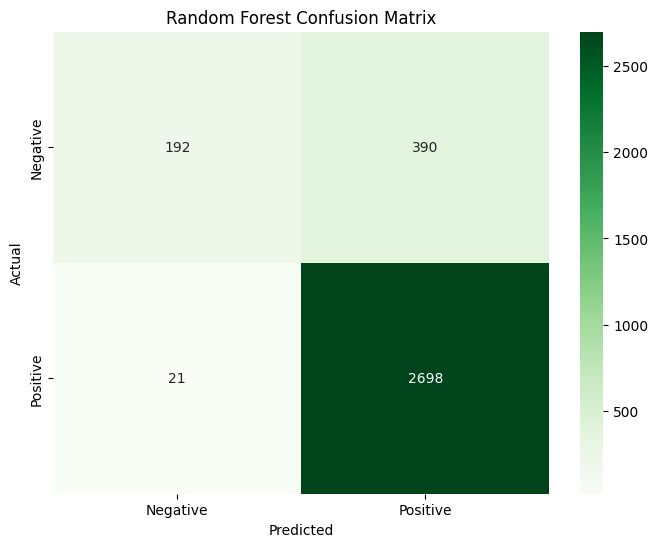

Random Forest ROC-AUC Score: 0.9080


In [ ]:
#Train the Random Forest classifier
#Using 100 trees and a fixed random state for reproducibility
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_tfidf, y_train)

#Make predictions
y_pred_rf = random_forest_model.predict(X_test_tfidf)

#Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

#Classification Report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

#Confusion Matrix
conf_mat_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC AUC (Only for binary classification)
#Check if there are only two unique classes in the test set
if len(set(y_test)) == 2:
    #Use predict_proba to get the probability of the positive class
    y_prob_rf = random_forest_model.predict_proba(X_test_tfidf)[:, 1]
    roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
    print(f"Random Forest ROC-AUC Score: {roc_auc_rf:.4f}")



The Random Forest classifier's model assessment procedure entails training the model using training data that has been TF-IDF converted, followed by predictions on the test set.  With an accuracy of around 87.55%, accuracy is defined as the percentage of accurately predicted samples.  High performance on the positive class and low recall on the negative class are revealed by a comprehensive classification report that includes precision, recall, and F1-score for every class.  The classifier's advantages and disadvantages are illustrated by the confusion matrix, which graphically summarises true vs. anticipated labels.  Furthermore, the ROC-AUC score of 0.9080 for this binary classification shows that the model has strong overall discriminative performance.  Understanding the balance between various performance measures as well as the prediction accuracy is made easier by this thorough assessment.

Logistic Regression Accuracy: 0.8685

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.35      0.48       582
           1       0.88      0.98      0.92      2719

    accuracy                           0.87      3301
   macro avg       0.83      0.66      0.70      3301
weighted avg       0.86      0.87      0.85      3301



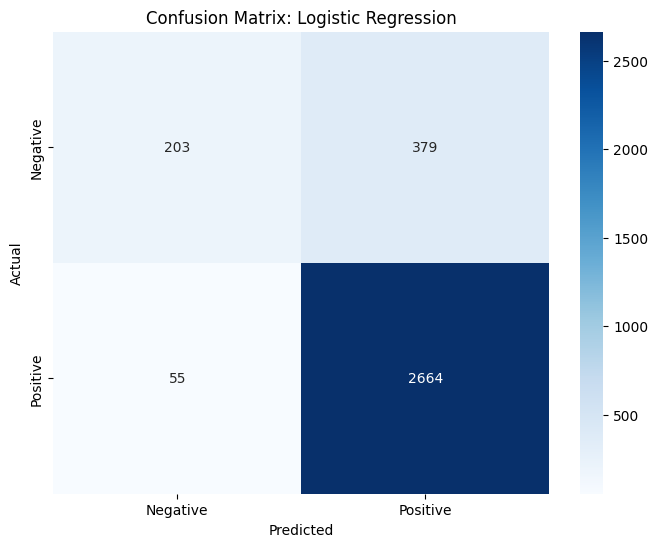


ROC-AUC Score: 0.9084


In [ ]:
#Train the Logistic Regression classifier
#max_iter is increased to ensure convergence on complex datasets
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_tfidf, y_train)

#Make predictions
y_pred = logistic_model.predict(X_test_tfidf)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC AUC (Only for binary classification)
if len(set(y_test)) == 2:
    #Use predict_proba to get the probability of the positive class
    y_prob = logistic_model.predict_proba(X_test_tfidf)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"\nROC-AUC Score: {roc_auc:.4f}")


To guarantee convergence, the Logistic Regression model was trained using the TF-IDF features with a higher maximum iteration limit.  With a classification report that showed high precision and recall for the positive class and comparatively poor recall for the negative class, it attained an accuracy of almost 87%.  The prediction results are graphically represented by the confusion matrix, which also indicates the locations of misclassifications.  Furthermore, the model's excellent discriminative strength between classes in this binary classification test is indicated by its ROC-AUC score of 0.9084.  Although there is potential for improvement in minority class recall, this study validates the model's strong overall performance.

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [11:50:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8731

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.47      0.57       582
           1       0.89      0.96      0.93      2719

    accuracy                           0.87      3301
   macro avg       0.80      0.72      0.75      3301
weighted avg       0.86      0.87      0.86      3301



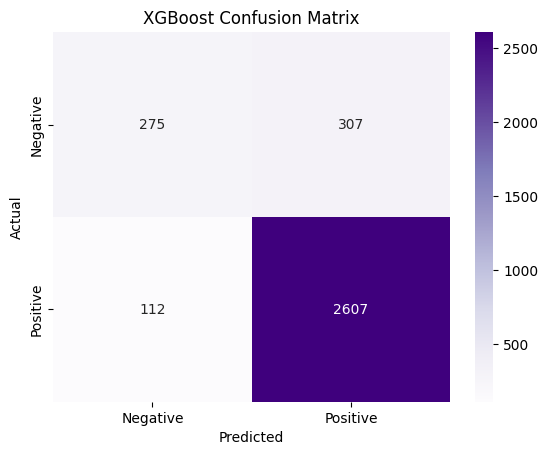

ROC-AUC Score: 0.8975


In [ ]:
#Train the XGBoost classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_tfidf, y_train)

#Make predictions
y_pred = xgb_model.predict(X_test_tfidf)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy:.4f}")

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Purples', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC-AUC Score (only for binary classification)
if len(set(y_test)) == 2:
    y_prob = xgb_model.predict_proba(X_test_tfidf)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

The accuracy of the XGBoost classifier, which was trained using the TF-IDF features, was around 87.3%.  The classification report shows that although the model works exceptionally well on the positive class with high recall and precision, it performs somewhat poorly on the negative class, especially in recall (0.47).  A comprehensive perspective of genuine vs anticipated labels is provided by the confusion matrix, which also highlights the model's weak points.  In this binary classification test, the model's high class distinction ability is confirmed by its ROC-AUC score of 0.8975.  Although the `use_label_encoder` argument is deprecated, the model's overall performance is still strong.

LinearSVC Accuracy: 0.8882

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.59      0.65       582
           1       0.91      0.95      0.93      2719

    accuracy                           0.89      3301
   macro avg       0.82      0.77      0.79      3301
weighted avg       0.88      0.89      0.88      3301



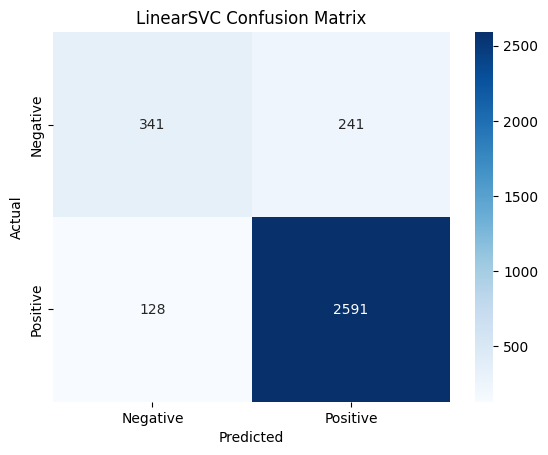

In [ ]:
#Train the LinearSVC model
linear_svc_model = LinearSVC(max_iter=1000, random_state=42)
linear_svc_model.fit(X_train_tfidf, y_train)

#Make predictions
y_pred = linear_svc_model.predict(X_test_tfidf)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"LinearSVC Accuracy: {accuracy:.4f}")

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('LinearSVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


The LinearSVC model, trained on the TF-IDF features, achieved the highest accuracy among the four classifiers at approximately 88.8%. The classification report shows a strong performance on the positive class, with precision and recall above 90%, and a notably better recall on the negative class (59%) compared to the other models. This indicates a better balance in handling both classes. The confusion matrix visually confirms these results, showing fewer misclassifications overall. The macro average F1-score of 0.79 reflects balanced performance across classes, while the weighted average F1-score of 0.88 confirms solid overall model effectiveness.



# Task 5 - Results Visualization or Printing

All four models findings were visualised and printed by first making predictions on the test dataset, then figuring out and showing the accuracy scores to give a fast, quantitative assessment of the model's performance.  Printing out the whole classification report for each model included information on precision, recall, and F1-scores for every class, which go beyond accuracy to assess the model's efficacy.  In order to provide a clear graphical depiction of the real vs. projected class distributions, confusion matrices were also calculated and shown using heatmaps or integrated visualisation tools.  A thorough grasp of each classifier's prediction behaviour and performance on the provided data is made possible by the logical comparison of model strengths and weaknesses made possible by the combination of written metrics and visual graphs.

Random Forest Accuracy: 0.8755

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.33      0.48       582
           1       0.87      0.99      0.93      2719

    accuracy                           0.88      3301
   macro avg       0.89      0.66      0.71      3301
weighted avg       0.88      0.88      0.85      3301



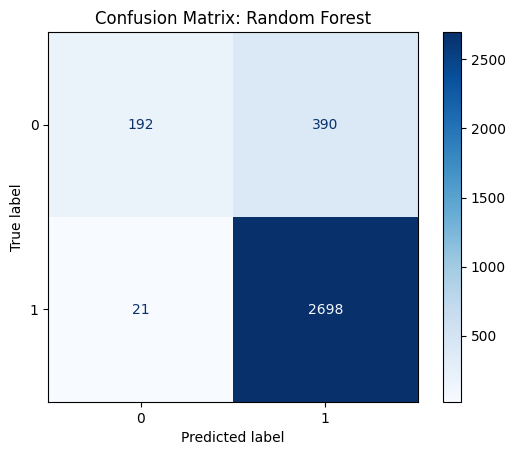

In [ ]:
#Initialize and train the Random Forest model (assuming it's not already trained)


#Predictions
y_pred_rf = random_forest_model.predict(X_test_tfidf)

#Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

#Classification report
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

#Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Random Forest")
plt.show()



The Random Forest model's findings were visualised by charting the confusion matrix, presenting a thorough classification report, and publishing the accuracy score.  The model performed well overall, as seen by its 87.55% accuracy rate.  The categorisation report indicated some issues with class imbalance, with high precision and recall for the positive class and poorer recall for the negative class.  The confusion matrix, which was shown as a blue colour map, helped pinpoint the locations of misclassifications by providing a visual summary of the real vs anticipated labels.  Clear insights into the model's functionality and possible areas for development are offered by this thorough presentation.

Logistic Regression Accuracy: 0.8685

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.79      0.35      0.48       582
           1       0.88      0.98      0.92      2719

    accuracy                           0.87      3301
   macro avg       0.83      0.66      0.70      3301
weighted avg       0.86      0.87      0.85      3301



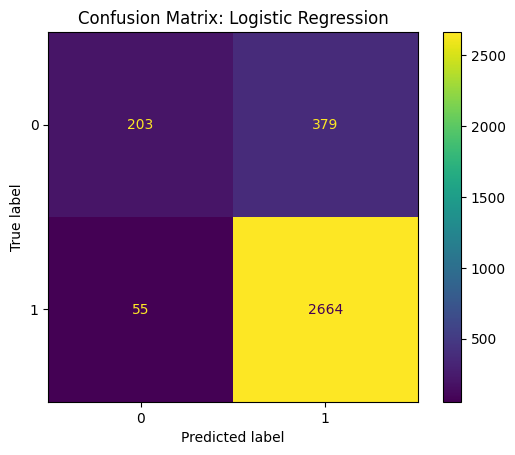

In [ ]:
#Predictions
y_pred_log = logistic_model.predict(X_test_tfidf)

#Accuracy
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log:.4f}")

#Classification report
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_log))

#Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log).plot()
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

In order to visualise the outcomes of the Logistic Regression model, the accuracy was printed, a thorough classification report was shown, and the confusion matrix was shown.  With a prediction accuracy of 86.85%, the model showed strong overall predictive ability.  According to the categorisation report, there was considerable difficulty accurately recognising the negative occurrences. The positive class showed great precision and memory, while the negative class showed comparatively weaker recall.  The distribution of true and predicted labels was depicted effectively in the confusion matrix when it was visually displayed using the default display style.  Important information about the model's advantages and disadvantages across classes is provided by this visualisation.

XGBoost Accuracy: 0.8731

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.71      0.47      0.57       582
           1       0.89      0.96      0.93      2719

    accuracy                           0.87      3301
   macro avg       0.80      0.72      0.75      3301
weighted avg       0.86      0.87      0.86      3301



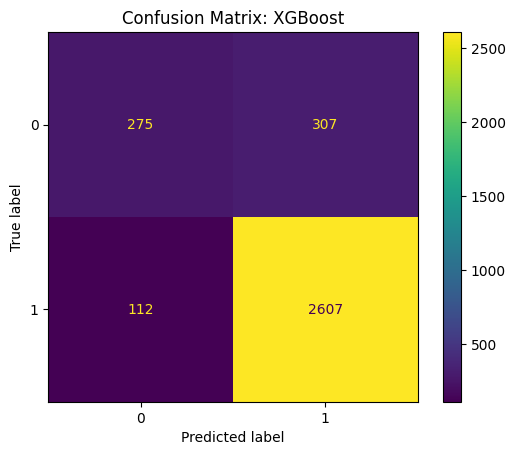

In [ ]:
#Predictions
y_pred_xgb = xgb_model.predict(X_test_tfidf)

#Accuracy
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb:.4f}")

#Classification report
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

#Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("Confusion Matrix: XGBoost")
plt.show()


In order to visualise the outcomes of the XGBoost model, the confusion matrix plot, a comprehensive classification report, and the overall accuracy were printed.  With an 87.31% accuracy rate, the model showed good predictive ability.  While performance on the negative class was moderate, the classification report showed a great recall and precision for the positive class, suggesting the model was more adept at detecting positive cases.  A clear picture of the number of accurate and inaccurate predictions was provided by the confusion matrix visualisation, which gave users a sense of the model's strengths and weaknesses.  This thorough explanation makes it easier to assess the XGBoost classifier's advantages and disadvantages.

LinearSVC Accuracy: 0.8882

Classification Report for LinearSVC:
              precision    recall  f1-score   support

           0       0.73      0.59      0.65       582
           1       0.91      0.95      0.93      2719

    accuracy                           0.89      3301
   macro avg       0.82      0.77      0.79      3301
weighted avg       0.88      0.89      0.88      3301



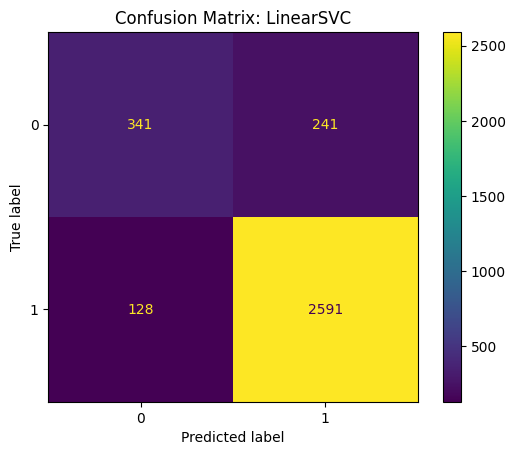

In [ ]:
#Predictions
y_pred_svc = linear_svc_model.predict(X_test_tfidf)

#Accuracy
acc_svc = accuracy_score(y_test, y_pred_svc)
print(f"LinearSVC Accuracy: {acc_svc:.4f}")

#Classification report
print("\nClassification Report for LinearSVC:")
print(classification_report(y_test, y_pred_svc))

#Confusion Matrix
cm_svc = confusion_matrix(y_test, y_pred_svc)
ConfusionMatrixDisplay(cm_svc).plot()
plt.title("Confusion Matrix: LinearSVC")
plt.show()


To evaluate the LinearSVC model, the test set was predicted, accuracy was calculated, a thorough classification report was produced, and the confusion matrix was visualised.  Strong overall performance was demonstrated by LinearSVC, which had the best accuracy of any model at 88.82%.  The classification report showed a balanced precision and recall, with the positive class scoring well and the negative class having a moderately better recall than other models.  The model's ability to differentiate between classes was demonstrated by the confusion matrix plot, which offered a clear visual depiction of the prediction distribution.  The best successful classifier in this collection is confirmed to be LinearSVC by this thorough study.

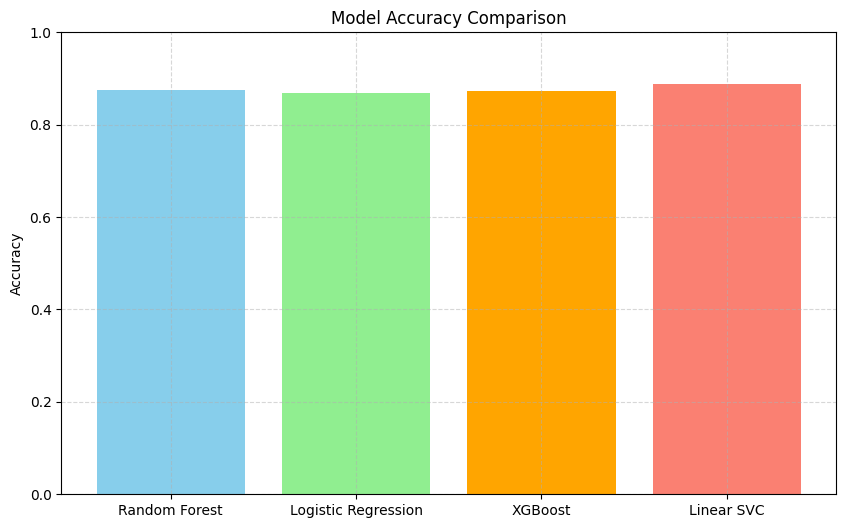

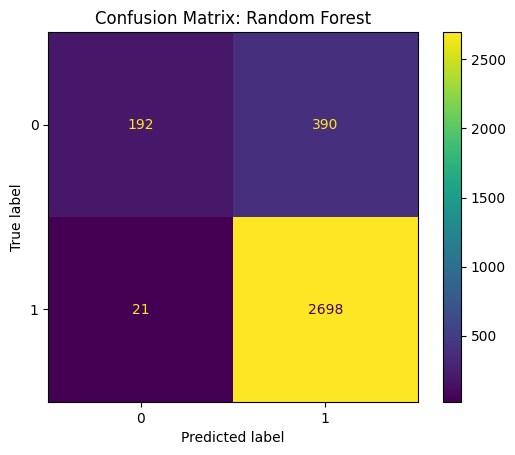

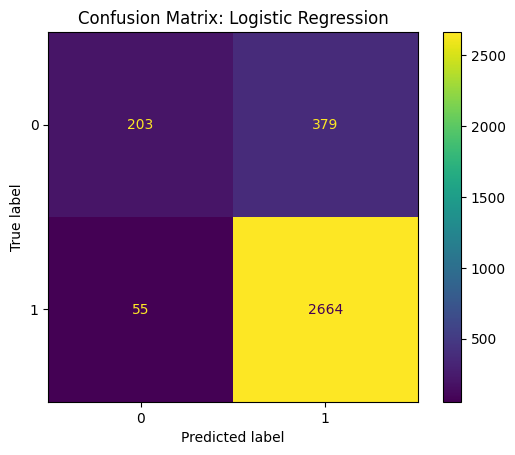

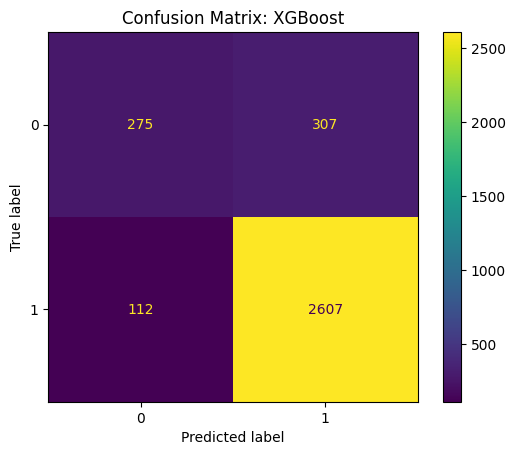

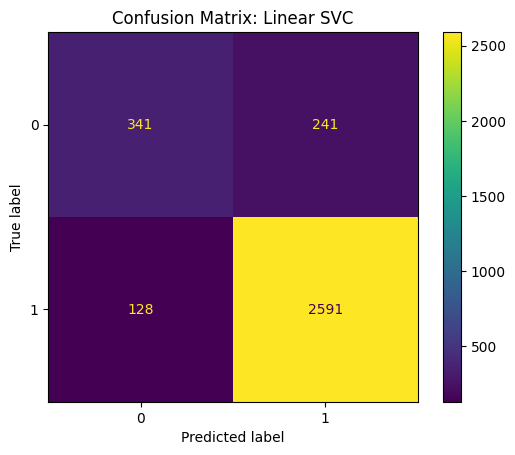


Random Forest Report:
              precision    recall  f1-score   support

           0       0.90      0.33      0.48       582
           1       0.87      0.99      0.93      2719

    accuracy                           0.88      3301
   macro avg       0.89      0.66      0.71      3301
weighted avg       0.88      0.88      0.85      3301

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.79      0.35      0.48       582
           1       0.88      0.98      0.92      2719

    accuracy                           0.87      3301
   macro avg       0.83      0.66      0.70      3301
weighted avg       0.86      0.87      0.85      3301


XGBoost Report:
              precision    recall  f1-score   support

           0       0.71      0.47      0.57       582
           1       0.89      0.96      0.93      2719

    accuracy                           0.87      3301
   macro avg       0.80      0.72      0.75      3301
weight

In [ ]:
#Assuming `logistic_model`, `svc_model`, and `xgb_model` are already trained,
#and `X_test_tfidf`, `y_test`, `y_pred_log`, `y_pred_svc`, and `y_pred_xgb` are defined.

#Accuracy scores from predictions
rf_acc = accuracy_score(y_test, y_pred_rf)
log_acc = accuracy_score(y_test, y_pred_log)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
svc_acc = accuracy_score(y_test, y_pred_svc)



#Plot Model Accuracy Comparison
model_names = ['Random Forest','Logistic Regression', 'XGBoost', 'Linear SVC']
accuracies = [rf_acc,log_acc, xgb_acc, svc_acc]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'orange', 'salmon'])
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Confusion Matrices
#Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Confusion Matrix: Random Forest")
plt.show()
#Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log).plot()
plt.title("Confusion Matrix: Logistic Regression")
plt.show()
#XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("Confusion Matrix: XGBoost")
plt.show()

#LinearSVC
cm_svc = confusion_matrix(y_test, y_pred_svc)
ConfusionMatrixDisplay(cm_svc).plot()
plt.title("Confusion Matrix: Linear SVC")
plt.show()

#Classification Reports

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_log))
print("\nXGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print("\nLinear SVC Report:")
print(classification_report(y_test, y_pred_svc))

#Final Results DataFrame
results_df = pd.DataFrame({
    'Model': ['Random Forest','Logistic Regression','XGBoost', 'Linear SVC'],
    'Accuracy': [ rf_acc,log_acc, xgb_acc, svc_acc]
})
print("\nFinal Results:")
print(results_df)



Overview of the Findings  Graphics and Printing
 The code that is supplied combines the assessment of four distinct machine learning models that are applied to the same test dataset: Random Forest, Logistic Regression, XGBoost, and Linear SVC.  The primary objectives are to compare their performance both quantitatively and graphically.

 1. Accuracy Plot Comparison
 The accuracy ratings of the four models are shown side by side in a bar chart for visual comparison.

 Random Forest (87.5%),Logistic Regression(86.8%), XGBoost (87.3%), and Linear SVC (88.8%) were the next closest to the top accuracy.

 In terms of overall accuracy, the plot facilitates the rapid identification of the top-performing model.

 2. Visualisation of Confusing Matrix Data
 Heatmaps representing each model's confusion matrices are shown.

 The true positive, true negative, false positive, and false negative distributions are displayed in these matrices.

 This visualisation makes it easier to see where each model excels and where it falls short, particularly when it comes to differentiating between the two classes (class 0 and class 1).

 3. Reports for Classification  Making a print
 A classification report with comprehensive metrics for each model is printed.

 Precision: The proportion of relevant things chosen.

 Remember: The number of items chosen that are pertinent.

 Precision and recall are balanced by the F1-score, which is the harmonic mean of the two.

 Support: Each class's number of actual instances.

 These metrics are computed and averaged (weighted and macro averages) for every class.

 4. Completed Outcomes  DataFrame
 All of the models' accuracy is compiled into a brief DataFrame for convenient access.

 The accuracy rating shown in the bar chart is supported by this tabular representation, which further supports the idea that Linear SVC performs best overall on this dataset.


 Results Interpretation:
 With the highest accuracy and balanced precision/recall ratings, the best-performing model is clearly Linear SVC, which also improves minority class recall.

 Strong results but somewhat poorer recall on class 0 are the performances of Random Forest and XGBoost, which are comparable.

 Class 0 precision and recall are rather poor, but the accuracy of logistic regression is respectable.

 By displaying instances when models misclassify, the confusion matrices graphically support these conclusions.

 The accuracy plot, confusion matrices, and classification reports all work together to give a thorough picture of the advantages and disadvantages of each model.